In [2]:
import sys
from pathlib import Path

# Go up one level from notebooks/ → project_root/
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.preprocessing.meei_dataset import MEEIDataset
from src.preprocessing.transforms import get_basic_transform
from src.models.efficientnet_b0_model_v1 import MultiPoseEfficientNetB0
from tqdm import tqdm

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [14]:
DATA_DIR = Path('../data/')
MAN_DIR = DATA_DIR / 'manifests'
RAW_DIR = DATA_DIR / 'raw'
CHECK_DIR = DATA_DIR / 'runs'
XLSX_PATH = RAW_DIR / 'pat_info.xlsx'
PAR_PATH = MAN_DIR / 'training_manifest_images_only.parquet'

In [7]:
basic_transform = get_basic_transform()

train_dataset = MEEIDataset(PAR_PATH, "train", basic_transform)
val_dataset = MEEIDataset(PAR_PATH, "val", basic_transform)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# -----------------------------
# Dataloaders
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)


Train size: 42
Val size: 9


In [36]:
model = MultiPoseEfficientNetB0(num_classes=6, pretrained=True, dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [37]:
def unpack_batch(batch, device):
    images = batch["images"].to(device)                 # [B, P, C, H, W]
    labels = batch["label"].to(device).long()
    return images, labels

In [26]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch in progress_bar:
        images, labels = unpack_batch(batch, device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        avg_loss_so_far = total_loss / total_samples
        avg_acc_so_far = total_correct / total_samples

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}",
            avg_loss=f"{avg_loss_so_far:.4f}",
            avg_acc=f"{avg_acc_so_far:.4f}"
        )

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

In [27]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc="Validation", leave=False)

    for batch in progress_bar:
        images, labels = unpack_batch(batch, device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        avg_loss_so_far = total_loss / total_samples
        avg_acc_so_far = total_correct / total_samples

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}",
            avg_loss=f"{avg_loss_so_far:.4f}",
            avg_acc=f"{avg_acc_so_far:.4f}"
        )

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

In [35]:
batch = next(iter(train_loader))
images, labels = unpack_batch(batch, device)

print("images shape:", images.shape, flush=True)
print("labels AFTER shift:", labels, flush=True)
print("min label:", labels.min().item(), "max label:", labels.max().item(), flush=True)

outputs = model(images)
print("outputs shape:", outputs.shape, flush=True)

images shape: torch.Size([4, 8, 3, 224, 224])
labels AFTER shift: tensor([1, 5, 1, 4], device='mps:0')
min label: 1 max label: 5
outputs shape: torch.Size([4, 6])


In [29]:
num_epochs = 15
best_val_loss = float("inf")
save_path = PROJECT_ROOT / "best_multipose_efficientnet_b0.pt"

print("Starting training...", flush=True)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1:02d}/{num_epochs}", flush=True)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
        f"lr={current_lr:.6f}",
        flush=True
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"Saved best model to {save_path}", flush=True)

print("Training complete.", flush=True)

Starting training...

Epoch 01/15


Epoch 01/15 | train_loss=1.9324 | train_acc=0.0238 | val_loss=1.8145 | val_acc=0.3333 | lr=0.000000
Saved best model to /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/best_multipose_efficientnet_b0.pt

Epoch 02/15


Epoch 02/15 | train_loss=1.9270 | train_acc=0.1190 | val_loss=1.8105 | val_acc=0.3333 | lr=0.000000
Saved best model to /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/best_multipose_efficientnet_b0.pt

Epoch 03/15


Epoch 03/15 | train_loss=1.9769 | train_acc=0.0952 | val_loss=1.8053 | val_acc=0.3333 | lr=0.000000
Saved best model to /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/best_multipose_efficientnet_b0.pt

Epoch 04/15


Epoch 04/15 | train_loss=1.9192 | train_acc=0.0238 | val_loss=1.7974 | val_acc=0.3333 | lr=0.000000
Saved best model to /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/best_multipose_efficientnet_b0.pt

Epoch 05/15


...

Epoch 11/15 | train_loss=1.9206 | train_acc=0.0476 | val_loss=1.8075 | val_acc=0.4444 | lr=0.000000

Epoch 12/15


Epoch 12/15 | train_loss=1.9018 | train_acc=0.0952 | val_loss=1.8040 | val_acc=0.3333 | lr=0.000000

Epoch 13/15


Epoch 13/15 | train_loss=1.9328 | train_acc=0.0714 | val_loss=1.8042 | val_acc=0.3333 | lr=0.000000

Epoch 14/15


Epoch 14/15 | train_loss=1.9393 | train_acc=0.0714 | val_loss=1.7958 | val_acc=0.4444 | lr=0.000000

Epoch 15/15


Epoch 15/15 | train_loss=1.9061 | train_acc=0.0476 | val_loss=1.8055 | val_acc=0.3333 | lr=0.000000
Training complete.


In [30]:
model = MultiPoseEfficientNetB0(
    num_classes=6,
    pretrained=False
).to(device)

model.load_state_dict(torch.load("../best_multipose_efficientnet_b0.pt", map_location=device))
model.eval()

MultiPoseEfficientNetB0(
  (encoder): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dN

In [31]:
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        images, labels = unpack_batch(batch, device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print("Pred HB:", all_preds + 1)
print("True HB:", all_labels + 1)

Pred HB: tensor([4, 1, 3, 5, 2, 5, 1, 1, 2])
True HB: tensor([6, 6, 3, 4, 2, 2, 1, 1, 5])


In [32]:
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
mae = mean_absolute_error(all_labels, all_preds)

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"MAE (HB): {mean_absolute_error(all_labels + 1, all_preds + 1):.4f}")

Accuracy: 0.4444
Macro F1: 0.3833
MAE (HB): 1.5556


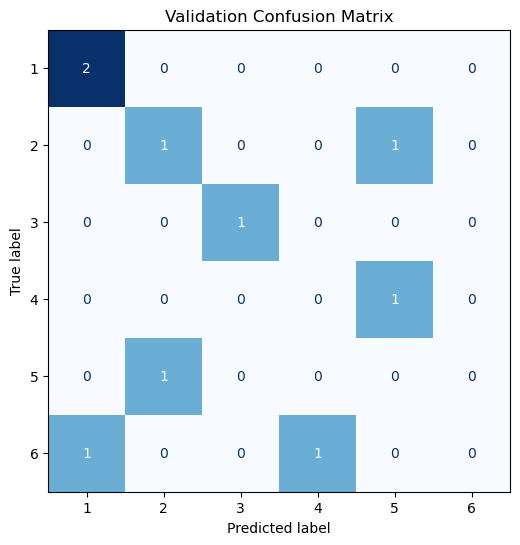

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds, labels=[0,1,2,3,4,5])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1,2,3,4,5,6]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Validation Confusion Matrix")
plt.show()

In [34]:
print("Predicted counts:", torch.bincount(all_preds, minlength=6))
print("True counts:     ", torch.bincount(all_labels, minlength=6))

Predicted counts: tensor([3, 2, 1, 1, 2, 0])
True counts:      tensor([2, 2, 1, 1, 1, 2])
